# AeroNet Lite — full demo

Runs **CSP repair**, **fleet GA**, **A*** delivery routing, and shows **two figures**.

The import cell clears cached `src.*` modules so Jupyter always loads your latest `visualization.py` and `main.py`. If anything still looks wrong, use **Kernel → Restart** and run all cells.

In [11]:
%matplotlib inline


 AERONET LAYOUT VALIDATION 

  R1 FAILED - Industrial not adjacent to School/Hospital
    R1 FAILED: Industrial cell (1, 9) adjacent to Hospital at (2, 9)
  R2 PASSED - Residential within 3 cells of a hub
  R3 PASSED - Hub within 2 cells of a charging pad
  R4 PASSED - Hospital has medical pickup within 1 cell

Layout validity = FALSE  (1 violation(s) total)

 AERONET LAYOUT VALIDATION 

  R1 PASSED - Industrial not adjacent to School/Hospital
  R2 PASSED - Residential within 3 cells of a hub
  R3 PASSED - Hub within 2 cells of a charging pad
  R4 PASSED - Hospital has medical pickup within 1 cell

Layout validity = TRUE - all CSP constraints satisfied.

Fleet (GA)
  Light: 0  Heavy: 8
  Cost: $14400  (budget used: 96.0%)
  Payload: 40 kg  |  Coverage (vs reachable demand): 100.0%
  Score: 51.00

 DELIVERY ASSIGNMENT TABLE
Job   Drone  Type    Hub      Pickup   Drop-off  Steps   Cost  Status
----------------------------------------------------------------------
J1    D1     Heavy   (0

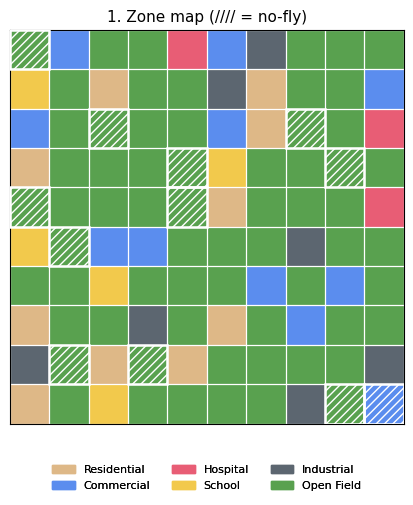

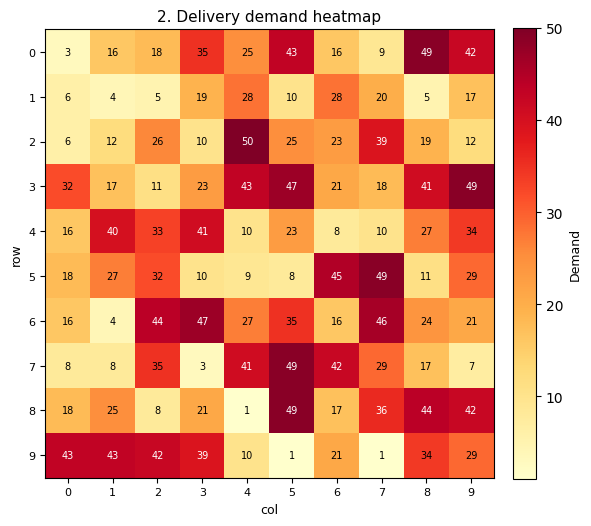

[Route] J1 assigned to D1 (Heavy, range=20 cells)
  hub -> pickup: cost=7.60  [(0, 7), (0, 6), (0, 5), (1, 5), (2, 5), (2, 4), (2, 3), (3, 3), (4, 3)]
  pickup -> drop-off: cost=4.00  [(4, 3), (3, 3), (2, 3), (1, 3), (1, 2)]
  drop-off -> hub: cost=5.80  [(1, 2), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7)]


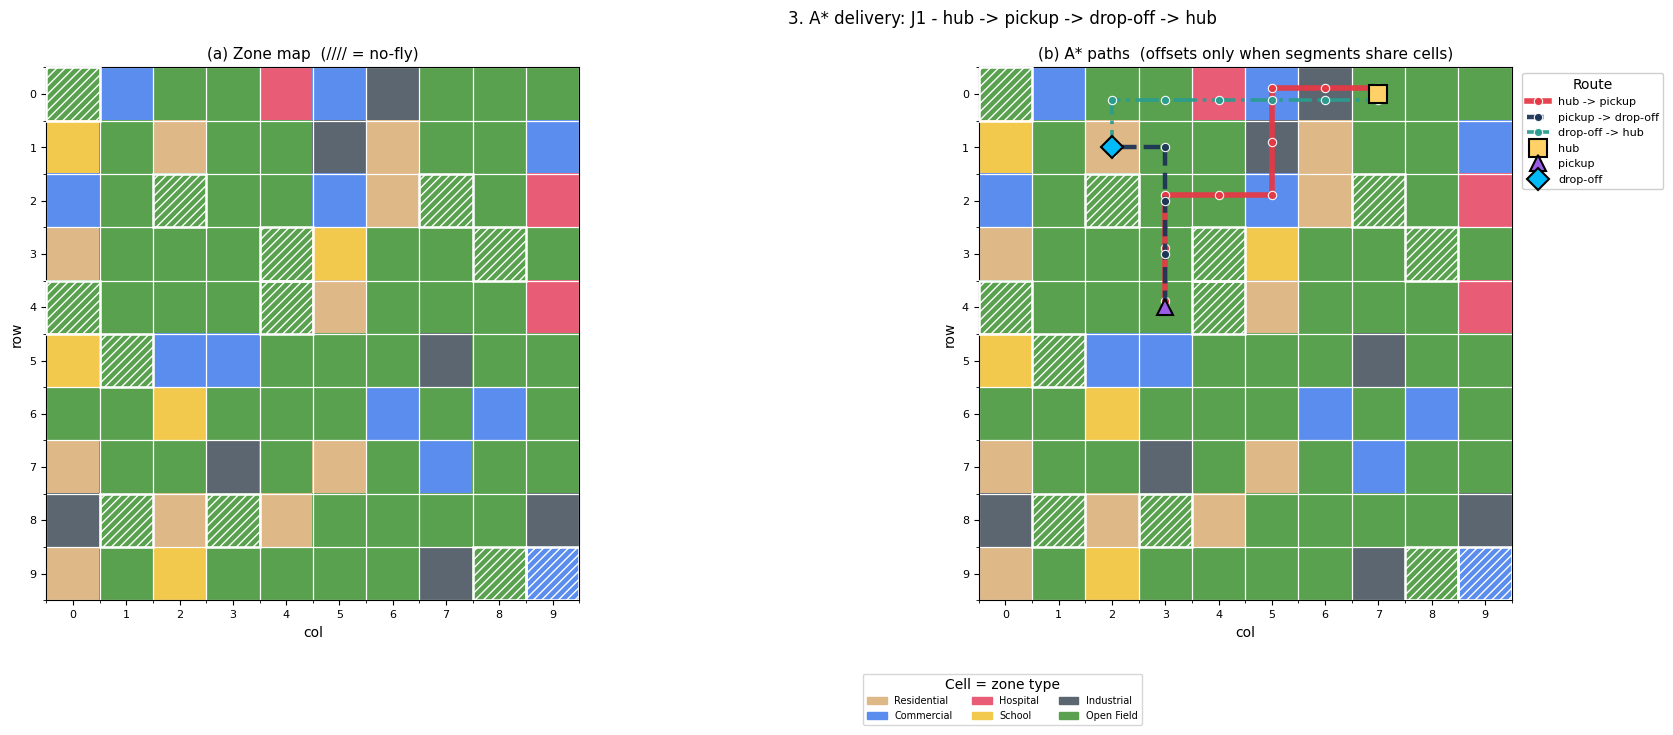


 PHASE 4 - DISRUPTION & REROUTING
  Drone : D1 (Heavy, range=20 cells)
  Status: in flight - arrived at pickup (4, 3)
  Next  : drop-off (1, 2)  ->  hub (0, 7)

  Original remaining path:
    pickup -> drop-off: 4 steps
    drop-off -> hub: 6 steps

Step 11: no-fly cell activated at (0, 4).
  D1 (J1): route crosses (0, 4) - rerouting from (4, 3).
  D1 rerouted using A*. Rerouted successfully (10 steps remaining).

  Updated remaining path:
    pickup -> drop-off: 4 steps
    drop-off -> hub: 6 steps


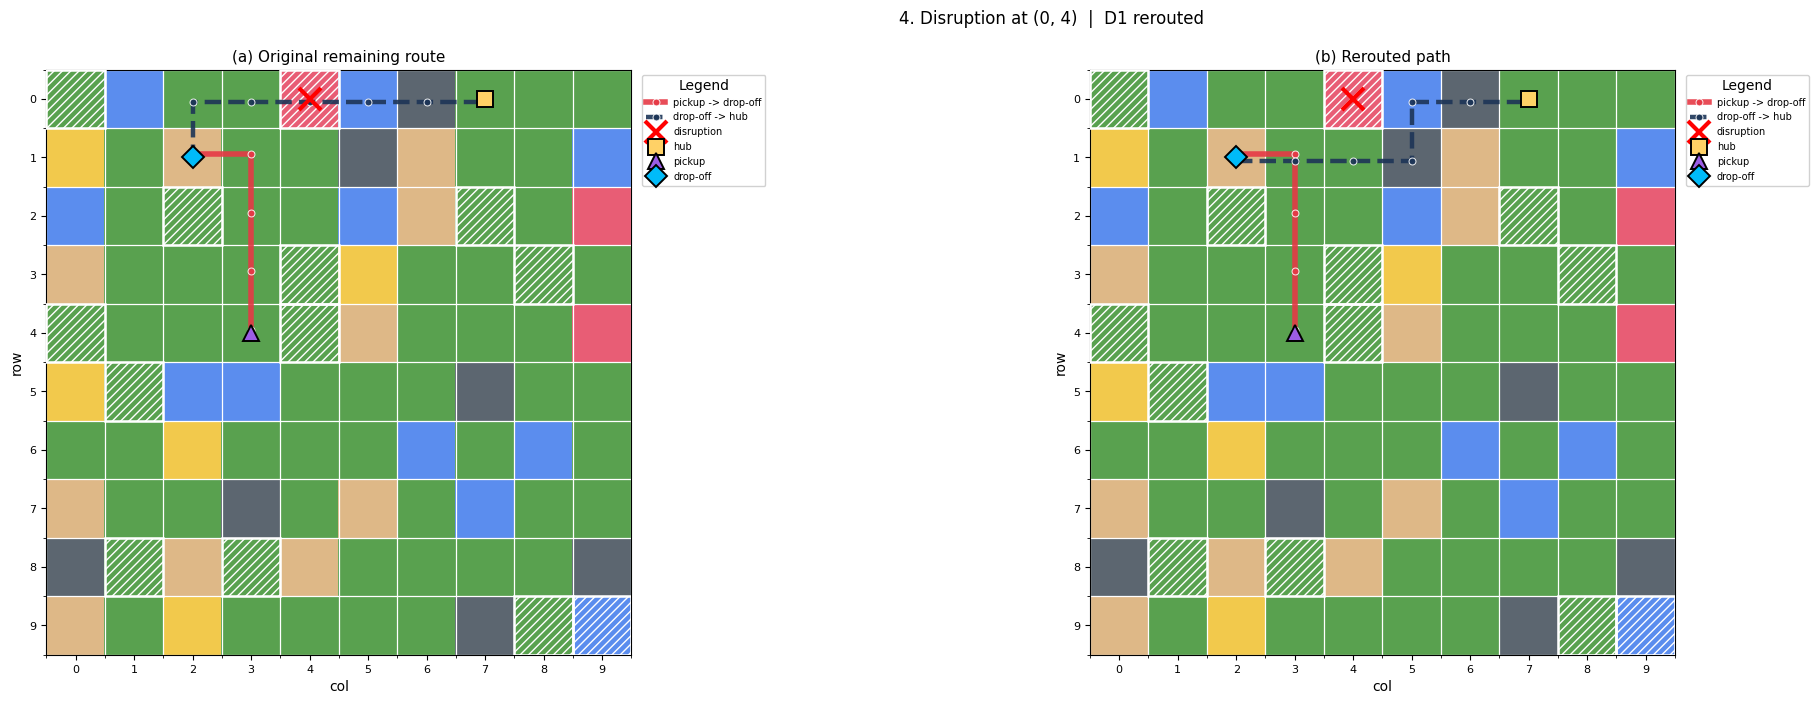


 PHASE 5 - MACHINE LEARNING PIPELINE

[1/4] Generating demand dataset ...
      800 samples | features: ['hour', 'day_of_week', 'temperature', 'weather', 'zone_type', 'density', 'is_hub']
[2/4] Training demand regression models ...

--- Demand Forecasting Metrics ---
Model                       MAE     RMSE
------------------------------------------
Linear Regression          6.89     8.77
Random Forest              7.14     8.68
  [saved] report\figures\demand_actual_vs_pred.png


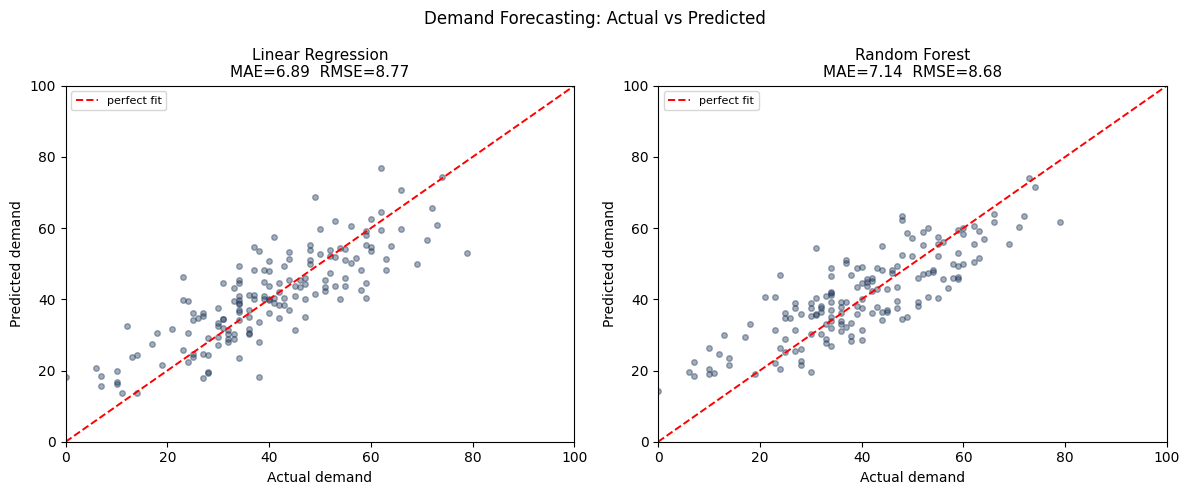

  [saved] report\figures\demand_feature_importance.png


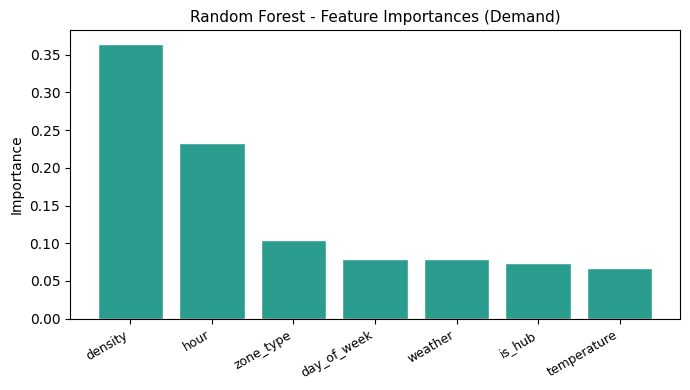


  Grid cell demand values updated via Random Forest forecast.

[3/4] Generating drone telemetry dataset ...
      Normal            : 500 samples
      Battery Anomaly   : 100 samples
      Route Anomaly     : 100 samples
      Sensor Spike      : 100 samples
[4/4] Training anomaly classifiers ...

--- Anomaly Detection Metrics ---

Decision Tree  (accuracy=100.0%)
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00       100
Battery Anomaly       1.00      1.00      1.00        20
  Route Anomaly       1.00      1.00      1.00        20
   Sensor Spike       1.00      1.00      1.00        20

       accuracy                           1.00       160
      macro avg       1.00      1.00      1.00       160
   weighted avg       1.00      1.00      1.00       160


Random Forest  (accuracy=100.0%)
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00       100
Battery Anomaly       1

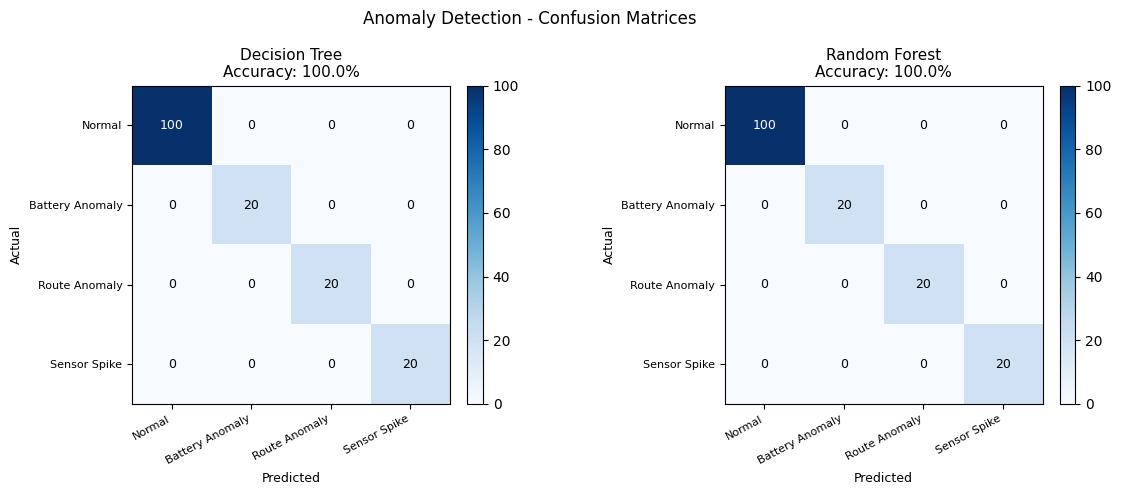


[Phase 5 complete]
 AERONET LITE -- 20-STEP DELIVERY SIMULATION

[Setup]
Step 1: Layout validation FAILED (1 violation(s)). Repairing...
Step 2: Layout repaired -- all CSP constraints satisfied.
Step 3: Fleet selected: 0 light drone(s), 8 heavy drone(s). Total cost: $14400.

[Delivery Assignment]
Step 4: 6 delivery job(s) generated.
Step 5: No-fly zones placed. Assigning drones with range constraints...
  J1 -> D1 (Heavy): hub(0, 7) -> pickup(4, 3) -> drop-off(1, 2) [18 steps]
  J2 -> D2 (Heavy): hub(0, 8) -> pickup(4, 9) -> drop-off(1, 6) [14 steps]
  J3 -> D3 (Heavy): hub(0, 9) -> pickup(3, 7) -> drop-off(2, 6) [14 steps]
  J4 UNASSIGNED -- no drone has sufficient range.
  J5 UNASSIGNED -- no drone has sufficient range.
  J6 -> D6 (Heavy): hub(1, 3) -> pickup(0, 2) -> drop-off(7, 0) [20 steps]
Step 6: 4 drone(s) launched. 2 job(s) unassigned.

[Movement Phase]
Step 7: Drones advance (2 cells/step).  In-flight: 4  Completed: 0
Step 8: Drones advance (2 cells/step).  In-flight: 4  Com

In [12]:
from pathlib import Path
import sys
import time

def project_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "src" / "main.py").is_file():
            return d
    return here


root = project_root()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Jupyter caches old src.* modules; reload(main) does not refresh dependencies.
# Drop them so visualization (and everything else) loads from disk.
for key in list(sys.modules.keys()):
    if key == "src" or key.startswith("src."):
        del sys.modules[key]

from src.main import run_full_demo

grid = run_full_demo(seed=time.time())